In [40]:
import numpy as np
from scipy import stats

> **Note:** This notebook is provided as-is from the course work.  
> The repository is structured to support clean re-runs and future extensions (data/, src/, figures/).

In [102]:
YEARS = 5
DAYS_PER_YEAR = 365 # Ignoring leap years
DAYS = YEARS * DAYS_PER_YEAR


# Oven variants
# Ignoring oven subsidy for the simulation. The subsidy effect
# can be easily computed ex post.

ovens = [
    {
        "oven_investment_eur": 0,
        "oven_maintenance_cost_per_year" : 15000,
        "oven_electricity_usage_per_hour" : 3.,
        "oven_gas_usage_per_hour": 2.7,
        "oven_failure_probability_per_day": .03,
        "oven_failure_cost_eur": 5000,
        "oven_capacity": 300,
        "oven_building_gas_savings": 0.,
        "oven_building_electricity_savings": .03,
        "oven_catastrophic_failure_rates_per_year": [0.02, 0.04, 0.06, 0.08, 0.1],
        "oven_catastrophic_failure_cost_eur": 500000,
        "oven_operating_hours_per_day": 16.,
        #"oven_subsidy_eur": 0,
        #"oven_subsidy_probability": 0,
    },
    {
        "oven_investment_eur": 160000,
        "oven_maintenance_cost_per_year" : 20000,
        "oven_electricity_usage_per_hour" : 2.7,
        "oven_gas_usage_per_hour": 2.2,
        "oven_failure_probability_per_day": .02,
        "oven_failure_cost_eur": 5000,
        "oven_capacity": 180,
        "oven_building_gas_savings": .05,
        "oven_building_electricity_savings": .1,      
        "oven_catastrophic_failure_rates_per_year": 0,
        "oven_catastrophic_failure_cost_eur": 0,   
        "oven_operating_hours_per_day": 16.,
        #"oven_subsidy_eur": 0,
        #"oven_subsidy_probability": 0,
    },
    {
        "oven_investment_eur": 240000,
        "oven_maintenance_cost_per_year" : 25000,
        "oven_electricity_usage_per_hour" : 2.5,
        "oven_gas_usage_per_hour": 2.,
        "oven_failure_probability_per_day": .02,
        "oven_failure_cost_eur": 5000,
        "oven_capacity": 200,
        "oven_building_gas_savings": .1,
        "oven_building_electricity_savings": .15,   
        "oven_catastrophic_failure_rates_per_year": 0,
        "oven_catastrophic_failure_cost_eur": 0,
        "oven_operating_hours_per_day": 16.,  
        #"oven_subsidy_eur": 0,
        #"oven_subsidy_probability": 0,
    },
    {
        "oven_investment_eur": 280000,
        "oven_maintenance_cost_per_year" : 30000,
        "oven_electricity_usage_per_hour" : 1.9,
        "oven_gas_usage_per_hour": 1.7,
        "oven_failure_probability_per_day": .01,
        "oven_failure_cost_eur": 5000,
        "oven_capacity": 220,
        "oven_building_gas_savings": .15,
        "oven_building_electricity_savings": .15,   
        "oven_catastrophic_failure_rates_per_year": 0,
        "oven_catastrophic_failure_cost_eur": 0,  
        "oven_operating_hours_per_day": 16.,
        #"oven_subsidy_eur": 50000,
        #"oven_subsidy_probability": 0.1,
    },
]

batch_sizes = np.array([120, 160, 200, 240])
# index order: [batch_size, year]
batch_size_probabilities = np.array([[.25, .30, .30, .35, .40],
                                     [.25, .25, .30, .30, .30],
                                     [.25, .25, .20, .20, .20],
                                     [.25, .20, .20, .15, .10]])

In [103]:
default_params = ovens[0] | {
    "gas_price_eur": 1.3,
    "electricity_price_eur": 1.8,
    # constant discount rate 0.05 per year:
    "daily_discount_factors": (1.05)**-(np.arange(DAYS)/DAYS_PER_YEAR),
    "building_gas_usage_per_day": 54.6,
    "building_electricity_usage_per_day": 318.0,
    "overnight_storage_cost_eur_per_day_unit": 2.,
    "batch_sizes": batch_sizes,
    "batch_size_probabilities": batch_size_probabilities,
}

In [120]:
# Important assumptions here: 
# 1) Production facility works 7 days per week.
# 2) Production (before going into the oven) never fails, only oven can fail.

# In the following, shape_prefix axes represent the indices range for different
# draws; the last axis (of size DAYS) represents the simulation day

def generate_daily_failures(oven_failure_probability_per_day, shape_prefix=()):
    shape_prefix = tuple(shape_prefix)
    return np.random.choice([True, False], size=shape_prefix + (DAYS,), replace=True,
                            p=[oven_failure_probability_per_day, 1-oven_failure_probability_per_day])

def generate_catastrophic_failure(oven_catastrophic_failure_rates_per_year,
                                 oven_catastrophic_failure_cost_eur, shape_prefix=()):
    
    pass #TODO
        
    

def generate_daily_batch_sizes(batch_sizes, batch_size_probabilities, shape_prefix=()):
    shape_prefix = tuple(shape_prefix)
    # int16 might be enough if memory is an issue
    sizes = np.empty(shape = shape_prefix + (YEARS, DAYS_PER_YEAR), dtype=np.int32)
    for y in range(YEARS):
        sizes[...,y,:] = np.random.choice(batch_sizes, size = shape_prefix + (DAYS_PER_YEAR,),
                                          p=batch_size_probabilities[:,y])
    sizes.shape = shape_prefix + (DAYS,)
    return sizes

# oven_capacities has shape shape_prefix, other arguments shape_prefix + (DAYS,)
def calculate_daily_storage(oven_capacities, daily_batch_sizes, daily_failures):
    # This would far better be done in cython / C / whatever
    # Probably can't be fully vectorised just with the built-in numpy functionality.
    storage = np.empty(daily_batch_sizes.shape, dtype=np.int32)
    current_storage = np.zeros(storage.shape[:-1], dtype=np.int32)
    for d in range(DAYS):
        current_storage += daily_batch_sizes[...,d]
        current_storage -= oven_capacities * np.logical_not(daily_failures[...,d])
        current_storage = np.fmax(current_storage, 0)
        storage[...,d] = current_storage
        #print(current_storage)
    return storage
    
def broadcast_days(x, shape_prefix):
    x = np.array(x)
    if len(x.shape) > 0 and x.shape[-1] == DAYS:
        return x
    else:
        return np.broadcast_to(x, shape_prefix+(DAYS,))
    
def broadcast_years(x, shape_prefix):
    x = np.array(x)
    if len(x.shape) > 0 and x.shape[-1] == YEARS: # this is a bit sloppy
        return x
    else:
        return np.broadcast_to(x, shape_prefix+(YEARS,))

def calculate_npv(oven_investment_eur,
                 oven_maintenance_cost_per_year,
                 oven_electricity_usage_per_hour,
                 oven_gas_usage_per_hour,
                 oven_failure_probability_per_day,
                 oven_failure_cost_eur,
                 oven_capacity,
                 oven_building_gas_savings,
                 oven_building_electricity_savings,
                 oven_catastrophic_failure_rates_per_year,
                 oven_catastrophic_failure_cost_eur,
                 oven_operating_hours_per_day,
                 gas_price_eur,
                 electricity_price_eur,
                 building_gas_usage_per_day,
                 building_electricity_usage_per_day,
                 overnight_storage_cost_eur_per_day_unit,
                 daily_discount_factors,
                 batch_sizes,
                 batch_size_probabilities,
                 shape_prefix=(),
                 return_details = False,
                 ):
    # Here we allow the parameters be constant throughout the simulation or
    # with given daily variation
    oven_electricity_usage_per_hour = broadcast_days(oven_electricity_usage_per_hour, shape_prefix)
    oven_gas_usage_per_hour = broadcast_days(oven_gas_usage_per_hour, shape_prefix)
    oven_operating_hours_per_day = broadcast_days(oven_operating_hours_per_day, shape_prefix)
    gas_price_eur = broadcast_days(gas_price_eur, shape_prefix)
    electricity_price_eur = broadcast_days(electricity_price_eur, shape_prefix)
    oven_failure_cost_eur = broadcast_days(oven_failure_cost_eur, shape_prefix)
    oven_maintenance_cost_per_year = broadcast_years(oven_maintenance_cost_per_year, shape_prefix)
    
    # First, draw batch sizes and daily failures. Other uncertainties might be
    # given in the input arguments. 
    
    daily_batch_sizes = generate_daily_batch_sizes(batch_sizes, batch_size_probabilities, shape_prefix)
    daily_failures = generate_daily_failures(oven_failure_probability_per_day, shape_prefix)
    daily_storage = calculate_daily_storage(oven_capacity, daily_batch_sizes, daily_failures)

    daily_storage_costs = daily_storage * overnight_storage_cost_eur_per_day_unit
    daily_repair_costs = daily_failures * oven_failure_cost_eur
    
    oven_daily_energy_costs = (np.logical_not(daily_failures)
        * oven_operating_hours_per_day * 
              (oven_electricity_usage_per_hour * electricity_price_eur)
           +  (oven_gas_usage_per_hour * gas_price_eur))
    
    
    building_daily_savings = (
        oven_building_gas_savings * building_gas_usage_per_day * gas_price_eur
      + oven_building_electricity_savings * building_electricity_usage_per_day
        * electricity_price_eur)
    
    
    daily_costs = (daily_storage_costs + daily_repair_costs + oven_daily_energy_costs
                   - building_daily_savings)
    
    yearly_discount_factors = daily_discount_factors[...,::DAYS_PER_YEAR]
    yearly_costs = oven_maintenance_cost_per_year
    
    daily_costs_npv = np.sum(daily_costs * daily_discount_factors, axis=-1)
    yearly_costs_npv = np.sum(yearly_costs * yearly_discount_factors, axis=-1)
    
    npv = -oven_investment_eur - daily_costs_npv - yearly_costs_npv
    if return_details:
        return {
    "NPV": npv, 
    "storage costs": np.sum(daily_storage_costs * daily_discount_factors, axis=-1),
    "repair costs": np.sum(daily_repair_costs * daily_discount_factors, axis=-1),
    "oven energy costs": np.sum(oven_daily_energy_costs * daily_discount_factors, axis=-1),
    "building energy savings": np.sum(building_daily_savings * daily_discount_factors, axis=-1),
    "investment and yearly maintenance": yearly_costs_npv + oven_investment_eur,
               }
    else: return npv


In [121]:
np.random.seed(42)
calculate_npv(**default_params, return_details=True)

{'NPV': np.float64(-455454.9386259974),
 'storage costs': np.float64(24493.599497841446),
 'repair costs': np.float64(249276.57415649085),
 'oven energy costs': np.float64(141306.4621992726),
 'building energy savings': np.float64(27810.954790042982),
 'investment and yearly maintenance': np.float64(68189.25756243539)}

In [122]:
params = default_params.copy()
params.update(ovens[1])
np.random.seed(42)
calculate_npv(**params, return_details=True)


{'NPV': np.float64(-2215032.1051990245),
 'storage costs': np.float64(1740452.9585231352),
 'repair costs': np.float64(194568.72462504712),
 'oven energy costs': np.float64(127542.38627064253),
 'building energy savings': np.float64(98450.97430304698),
 'investment and yearly maintenance': np.float64(250919.0100832472)}

In [123]:
params = default_params.copy()
params.update(ovens[2])
np.random.seed(42)
calculate_npv(**params, return_details=True)

{'NPV': np.float64(-661165.6727302265),
 'storage costs': np.float64(145481.71913965812),
 'repair costs': np.float64(194568.72462504712),
 'oven energy costs': np.float64(118016.82365081782),
 'building energy savings': np.float64(150550.35728935566),
 'investment and yearly maintenance': np.float64(353648.762604059)}

In [124]:
params = default_params.copy()
params.update(ovens[3])
np.random.seed(42)
calculate_npv(**params, return_details=True)

{'NPV': np.float64(-492019.62043408724),
 'storage costs': np.float64(38732.49334648132),
 'repair costs': np.float64(102123.27668992087),
 'oven energy costs': np.float64(91083.4842317403),
 'building energy savings': np.float64(156298.14895892606),
 'investment and yearly maintenance': np.float64(416378.5151248708)}

In [131]:
SS = (10000,) # sample size
FS = SS + (DAYS,)
np.random.seed(42)
randomised_params = {
    "gas_price_eur": np.random.lognormal(1.3, .7, FS),
    "electricity_price_eur": np.random.lognormal(1.8, .7, FS),
    "oven_failure_cost_eur": np.random.normal(1, .25, FS)*5000
}
print(randomised_params["oven_failure_cost_eur"])

[[5145.23734041 2255.07969934 5843.2437889  ... 5832.21771355
  2295.01708555 4572.96029377]
 [5994.40955277 4429.53690337 5242.81858345 ... 4692.44155615
  4144.11280915 2171.89711803]
 [5897.96715422 5684.60329559 5908.40780561 ... 7219.61971928
  4575.10398024 3828.54401144]
 ...
 [4747.75662355 4326.72563685 2534.38291996 ... 3747.61681863
  4418.66548149 7338.06048475]
 [6027.30978094 6262.61254794 3903.99957306 ... 3956.7068737
  4227.91942067 2982.81199808]
 [5854.93325102 1934.87807188 4887.81343279 ... 3662.72636755
  3857.60849959 3095.89466396]]


In [132]:
results = []
for oven in ovens:
    params = default_params.copy()
    params.update(oven)
    params.update(randomised_params)
    params['shape_prefix']=SS
    np.random.seed(155554)
    results.append(calculate_npv(**params, return_details=True))
    

In [133]:
for i, oven in enumerate(results):
    print("Oven", i, "mean", "sd")
    for key, valuearr in oven.items():
        print(key, np.mean(valuearr), np.std(valuearr))
        

Oven 0 mean sd
NPV -818590.2008401589 36014.05128816488
storage costs 23747.293860112302 3920.6558685095065
repair costs 242835.45434457192 33751.841238910034
oven energy costs 603224.4623742107 11279.290435161867
building energy savings 119406.26730117142 2230.8872585187087
investment and yearly maintenance 68189.25756243538 1.4551915228366852e-11
Oven 1 mean sd
NPV -2664566.056910453 1304904.498655659
storage costs 2124123.9527455093 1295802.1165305672
repair costs 161689.29577608273 27674.106084114777
oven energy costs 546583.1432043712 10136.942791864425
building energy savings 418749.3448987575 7446.766146385596
investment and yearly maintenance 250919.0100832471 1.1641532182693481e-10
Oven 2 mean sd
NPV -503997.7311107147 43842.04349645381
storage costs 121333.63036484833 23406.895798864425
repair costs 161689.29577608273 27674.106084114777
oven energy costs 505814.2866612873 9385.889198641866
building energy savings 638488.2442955626 11182.05316571335
investment and yearly maint

In [145]:
# Basic Old oven catastrophic failure estimates
oven0_survival_prob = np.prod(1-np.array(ovens[0]["oven_catastrophic_failure_rates_per_year"]))
1-oven0_survival_prob

np.float64(0.26775654400000004)

In [148]:
(1-oven0_survival_prob) * -500000

np.float64(-133878.27200000003)

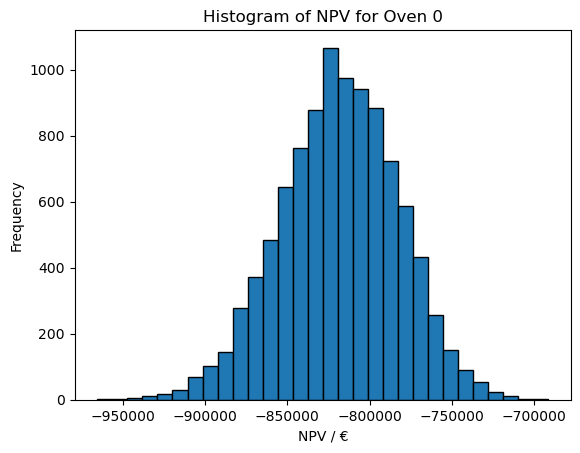

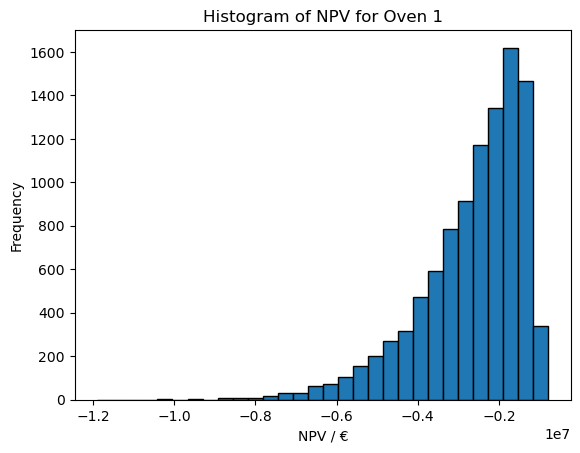

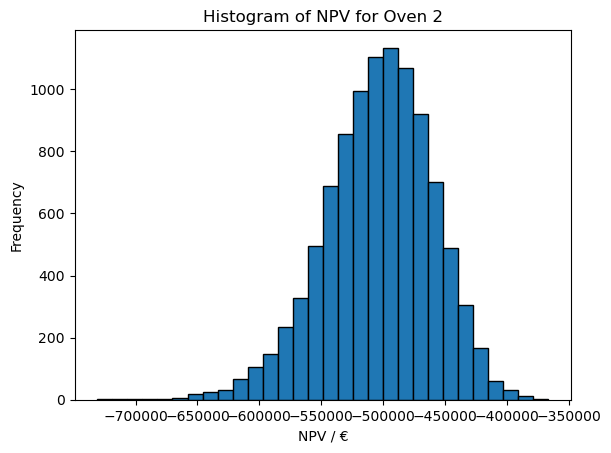

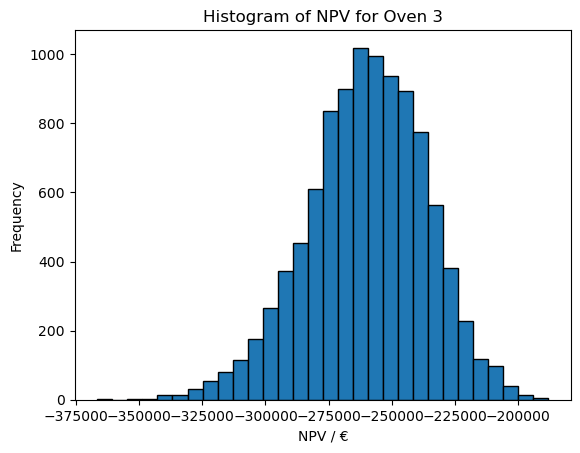

In [157]:
import matplotlib.pyplot as plt

for i, oven in enumerate(results):
    f, ax = plt.subplots(1)
    ax.set_title("Histogram of NPV for Oven %d" % i)
    ax.set_xlabel("NPV / €")
    ax.set_ylabel("Frequency")
    ax.hist(oven['NPV'], bins=30, edgecolor='black')
    f.savefig("../images/npv%d.pdf" % i)
    

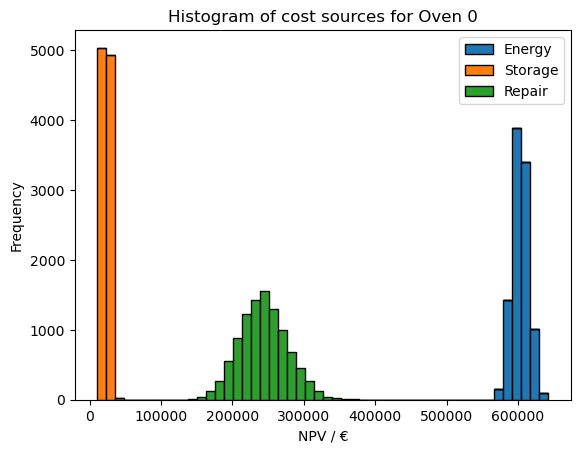

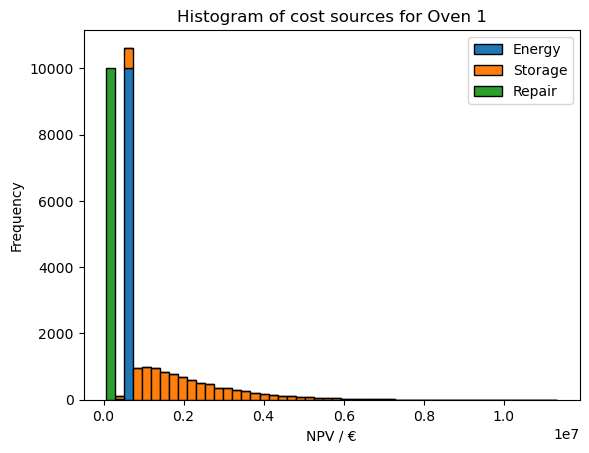

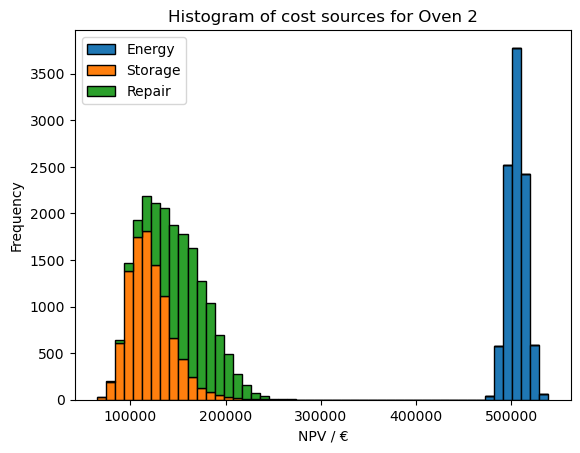

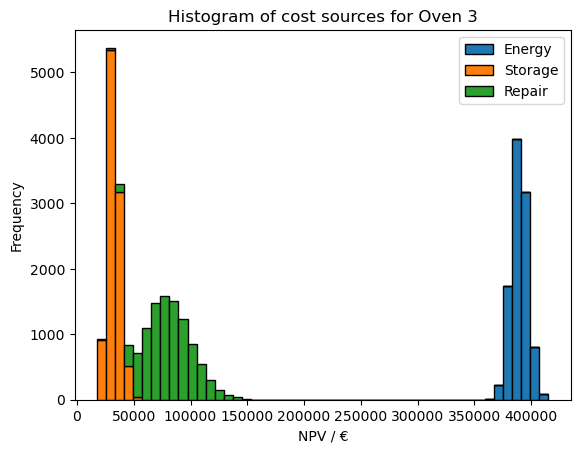

In [159]:

labels = ['Energy', 'Storage', 'Repair']
colors = ['tab:blue', 'tab:orange', 'tab:green']

for i, oven in enumerate(results):
    f, ax = plt.subplots(1)
    ax.set_title("Histogram of cost sources for Oven %d" % i)
    ax.set_xlabel("NPV / €")
    ax.set_ylabel("Frequency")
    ax.hist([oven["oven energy costs"], oven["storage costs"], oven["repair costs"]],
            bins=50, label=labels, color=colors, stacked=True, edgecolor='black')
    ax.legend()
    f.savefig("../images/costsrc%d.pdf" % i)